In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv('WA_Marketing-Campaign.csv')
df.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


1. Why is it important that this study was conducted as a designed experiment, with
stores randomly assigned to promotions, rather than simply observing which promotions stores
chose to use?

A: It's important to have a designed experiment to have a random sample. It also allows us to see if promotion is the root cause of sales, not any other factor.Random samples reduce biases and represent the population so that we can generalize and provide conclusion. 

2. What is the experimental unit, treatment, and outcome in this experiment?

A: The experimental unit is the store. The treament is one of the three promotional campaigns. The outcome is by weekly sales.

3. The company wants to determine whether promotion strategy affects sales.
Is this primarily an inference or prediction problem? Explain why.

A: This is primarily an inference problem because we aren't predicting an outcome. Rather we are recognizing what has occured and are trying to understand the cause and effect relationship between the input and outputs.

Part 2

In [47]:
total_sales = df.groupby(['week', 'Promotion'])['SalesInThousands'].sum().reset_index()
total_sales

,week,Promotion,SalesInThousands
0,1,1,2504.51
1,1,2,2243.32
2,1,3,2621.48
3,2,1,2447.97
4,2,2,2236.38
5,2,3,2629.61
6,3,1,2527.32
7,3,2,2242.94
8,3,3,2555.76
9,4,1,2513.23


<Axes: xlabel='Promotion', ylabel='SalesInThousands'>

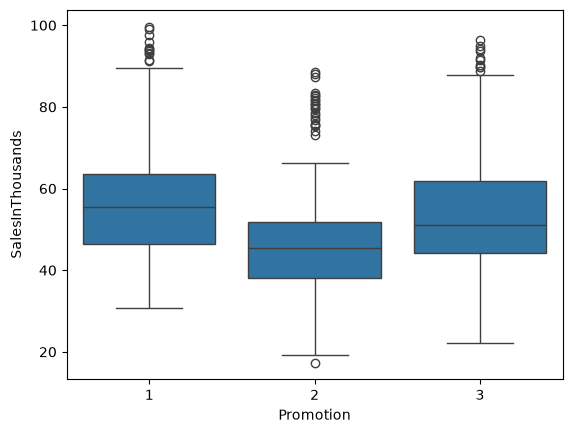

In [48]:
import seaborn as sns

sns.boxplot(
    data=df,
    x='Promotion',
    y='SalesInThousands'
)



2.2
The boxplot shows that there were some differences across the promotions. Promo 1 seeming to have the best on average followed by promo 3 and promo 2. There is also substaintial variation within the promotions, this could be because of store/market sizes. 

2.3
Not necessarily, we can see that sales are higher under promo 1, but that is the observed sample. We need to do some more digging before we make a conclusion. 

#3.1

It tells us if one group has sold more on average than the other. If one group has a higher mean than the other, then the difference will shows us by how much the average sales is different than the other group.

Theta being greater than 0 means that the promotion group 2 has better average sales than promotion group 1. Thetha being equal to 0 means that the average sales between the two promotions are the same. Theta less than 0 means that promotion 2 had less average sales than promotion 1.



In [ ]:
avg_sales = df.groupby(df['Promotion'])['SalesInThousands'].mean().reset_index()
avg_sales

mean = avg_sales['SalesInThousands'].values
mean[0]
diff = mean[1] - mean[0]
print(avg_sales)
print(diff)



   Promotion  SalesInThousands
0          1         58.099012
1          2         47.329415
2          3         55.364468
-10.769596734289962


3.3
The difference between sales under promo 2 were about 10.77 units lower than promo 1. This means that sales under promo 2 were $10.7k lower per store.

In [54]:
#im pulling from the emails colab 
x1 = df.loc[df['Promotion'] == 1, 'SalesInThousands'].to_numpy()
x2 = df.loc[df['Promotion'] == 2, 'SalesInThousands'].to_numpy()

rng = np.random.default_rng(6021)
B = 5000

boot_diff = np.empty(B)

for b in range(B):
    control = rng.choice(
        x1,
        size = len(x1),
        replace=True
    )
    treatment = rng.choice(
        x2, 
        size = len(x2),
        replace=True 
    )
    boot_diff[b] = (
        treatment.mean()
        - control.mean()
    )

lower, upper = np.percentile(
    boot_diff,
    [2.5, 97.5]
)
print(lower)
print(upper)

-14.006964621474532
-7.518138854527455


3.5
The 95% confidence inferval is (-14, -7.5) thousand dollars. This shows us that all of promo 2 iterations produce a lower average weekly sales than promo 1. 

3.6
Suppossing my confidence interval contained a 0 it would suggest that in the bootstrapping there was a case that sales were on average similar. That scenario assumes that there is no difference in promo strategies. However, the majority of the CI would still lean negative because 0 would be a tail. 

4.1
no, our theta is negative. meaning that promo 2 actually decreases sales on average relative to promo 1. 

4.2 
There is no evidence that it increases by 2k compared to promo 1. We would need to see our confidence interval with a postive 2 in it. (-14, 2), even then it wouldnt be convincing. To get to that point we would want to be at (2, 2+n).

4.3
My recommendation for this argument is to go with promo 1. The defense is simply that fact that the confidence interval when comparing the two promos showed that on the lower end promo 2 was -$7.5k lower on average than promo 1. I would need to see the lower end start at 2k, which is not the case here.

(ignore for grading) However I would like to collect more data. My issue with this data is that we are comparing to other promotions. I would need to see if these promotions were positively impacting sales in the first place, by comparing these promos to a non-promo strategy, maybe that is promo 2 and i just dont know it. 

In [ ]:
df.groupby('Promotion')['SalesInThousands'].agg(['count','mean','std'])


,count,mean,std
Promotion,,,
1,172,58.099012,16.553782
2,188,47.329415,15.108955
3,188,55.364468,16.766231


5.1
H_0 = mu1 = mu2 = mu3
in the context of this experiment is the mean of promo 1, 2, and 3. Null hypothesis in the scenario is trying to figure out if the promos are all similar or vary in any way. This means the three promotions have the same average weekly sales.

5.2 
If ANOVA results do not support then the natural next step is to explore which ones differ. We would compare each one to the other like below.

In [64]:
x1 = df.loc[df['Promotion'] == 1, 'SalesInThousands'].to_numpy()
x2 = df.loc[df['Promotion'] == 2, 'SalesInThousands'].to_numpy()
x3 = df.loc[df['Promotion'] == 3, 'SalesInThousands'].to_numpy()

test1 = x1.mean() - x2.mean()
test2 = x1.mean() - x3.mean()
test3 = x2.mean() - x3.mean()
print(test1)
print(test2)
print(test3)



10.76959673428997
2.734543542800594
-8.035053191489375


5.3
From what I was able to pick up, it seems that the arguement is that there is a 5% risk of false positive when we run it individually. That risk increases as we add more comparisons. 

6.1
The goal changed from explaining a cause of sales to forecasting/projecting the sales.

6.2
Some good columsn would be promotion, market size, and age of store. Promotion should give us the expected jump in sales, market size should give us the magnitude of sales, age of store will be a good predictor because of its length of history and solidification in communities

6.3
A model is good if it is accurate with data it was not trained on. I would evalute the success of the model by basing it on how far off it was from the actual data. I wish we went over the MAE/RMSE/R^2 that ai is telling me about, but idk. 



I used AI. I used Grok. I used it as a Tutor and to help guide me through the work. It acted more as a supervisor to keep pushing me and a TA to explain and walk me through ideas, even using visuals to help me. Rather than a cheat sheet. Part of the prompt was "You are a helpful, informative, and friendly PhD TA.", I was hoping to get Beau when I needed him.